# Forward Kinematics — 2-DOF Planar Robotic Arm

This notebook establishes the mathematical foundation of the 2-DOF robotic arm developed in this project.

The objective is to implement **forward kinematics**, which determines the Cartesian position of the robot's end effector from its joint angles and link lengths.

The mathematical model developed here will later be used for:

* Robot animation and simulation
* Automatic configuration-space exploration
* Dataset generation
* Workspace visualization
* Neural-network-based inverse kinematics
* Motion planning
* Physical robot implementation


## 1. Objective

The first stage of the project is to construct a mathematical representation of a two-link planar robotic arm.

The robot has:

* Two rotational joints
* Two rigid links
* A fixed base
* A 2D Cartesian workspace

The main relationship we want to establish is:

$$
(\theta_1,\theta_2) \rightarrow (x,y)
$$

where:

* \(\theta_1\) is the first joint angle
* \(\theta_2\) is the second joint angle
* \(x,y\) represent the end-effector position
* \(L_1,L_2\) represent the link lengths

This relationship is known as **forward kinematics**.


## 2. Robot Configuration

The initial robot is defined as a 2-DOF planar manipulator.

### Physical parameters

| Parameter             |     Value |
| --------------------- | --------: |
| Link 1 length \(L_1\) |     10 cm |
| Link 2 length \(L_2\) |     10 cm |
| Base position         | \((0,0)\) |
| Number of joints      |         2 |
| Workspace             |        2D |

The base of the robot is fixed at the origin:

$$
O=(0,0)
$$

Both joints are rotational.


## 3. Coordinate System and Angle Convention

A Cartesian coordinate system is defined with the robot's base at the origin.

The positive \(x\)-axis points to the right and the positive \(y\)-axis points upward.

Angles are measured counter-clockwise from the positive \(x\)-axis.

Therefore:

$$
\theta=0^\circ
$$

corresponds to a horizontal link pointing to the right, while:

$$
\theta=90^\circ
$$

corresponds to a vertical link pointing upward.

The second joint angle \(\theta_2\) is defined **relative to the first link**. Therefore, the absolute orientation of Link 2 is:

$$
\theta_1+\theta_2
$$


## 4. Forward Kinematics

For Link 1, the position of Joint 2 is:

$$
x_1=L_1\cos(\theta_1)
$$

$$
y_1=L_1\sin(\theta_1)
$$

For Link 2, its absolute orientation is:

$$
\theta_1+\theta_2
$$

Therefore, the end-effector position is:

$$
\boxed{x=L_1\cos(\theta_1)+L_2\cos(\theta_1+\theta_2)}
$$

$$
\boxed{y=L_1\sin(\theta_1)+L_2\sin(\theta_1+\theta_2)}
$$

These equations form the mathematical core of the robot model and will be reused throughout the project.


### 1.Define the Robot

In [1]:
#assign the lengths of the two links
import numpy as np
L1 = 10.0  # cm
L2 = 10.0  # cm

In [19]:
#define the forward kinematics function
def forward_kinematics(theta1, theta2):
    #convert angles to radians
    theta1 = np.radians(theta1)  # degrees to radians
    theta2 = np.radians(theta2)  # degrees to radians

    #calculate the positions of the base, first joint, and end effector
    x0, y0 = 0.0, 0.0
    x1 = np.round(L1 * np.cos(theta1), 10)
    y1 = np.round(L1 * np.sin(theta1), 10)

    x2 = np.round(x1 + L2 * np.cos(theta1 + theta2), 10)
    y2 = np.round(y1 + L2 * np.sin(theta1 + theta2), 10)

    return (x0, y0), (x1, y1), (x2, y2)


In [16]:
#test the function with some example angles - vertical position
theta1 = 90  # degrees
theta2 = 0 # degrees

(x0, y0), (x1, y1), (x2, y2) = forward_kinematics(theta1, theta2)
print(f"Base: x = {x0:.2f} cm, y = {y0:.2f} cm")
print(f"First joint: x = {x1:.2f} cm, y = {y1:.2f} cm")
print(f"End effector: x = {x2:.2f} cm, y = {y2:.2f} cm")



Base: x = 0.00 cm, y = 0.00 cm
First joint: x = 0.00 cm, y = 10.00 cm
End effector: x = 0.00 cm, y = 20.00 cm


### For better mathematical model we will create a class Robot Object to change the shape of the robot hand when needed

In [2]:
# create Robot Arm class
class RobotArm2DOF:
    def __init__(self, L1, L2):
        self.L1 = L1
        self.L2 = L2
        theta1_limits=(-90, 180),
        theta2_limits=(-120, 120)

    def forward_kinematics(self, theta1, theta2):
        #convert angles to radians
        theta1 = np.radians(theta1)  # degrees to radians
        theta2 = np.radians(theta2)  # degrees to radians

        #calculate the positions of the base, first joint, and end effector
        x0, y0 = 0.0, 0.0
        x1 = np.round(self.L1 * np.cos(theta1), 10)
        y1 = np.round(self.L1 * np.sin(theta1), 10)

        x2 = np.round(x1 + self.L2 * np.cos(theta1 + theta2), 10)
        y2 = np.round(y1 + self.L2 * np.sin(theta1 + theta2), 10)

        return (x0, y0), (x1, y1), (x2, y2)


In [3]:
# assign object of RobotArm2DOF class
robot = RobotArm2DOF(10, 10) # lengths of the two links

origin, joint2, end_effector = robot.forward_kinematics(90, 0)
print(f"Origin: ({origin[0]:g}, {origin[1]:g})")
print(f"Joint 2: ({joint2[0]:g}, {joint2[1]:g})")
print(f"End Effector: ({end_effector[0]:g}, {end_effector[1]:g})")



Origin: (0, 0)
Joint 2: (0, 10)
End Effector: (0, 20)


### 1.2 add forward kinematics validation tests

Before we move on, we will test these five configurations:

|   θ₁ |   θ₂ | Expected idea          |
| ---: | ---: | ---------------------- |
|   0° |   0° | Fully horizontal right |
|  90° |   0° | Fully vertical         |
|  90° | -90° | L-shaped               |
|  45° |  45° | Bent upward/right      |
| 180° |   0° | Fully horizontal left  |


In [21]:
configurations = [
    (0, 0, "Fully horizontal right"),
    (90, 0, "Fully vertical"),
    (90, -90, "L-shaped"),
    (45, 45, "Bent upward/right"),
    (180, 0, "Fully horizontal left"),
]

print("| Configuration | theta1 | theta2 | Origin | Joint 2 | End Effector |")
print("|---|---:|---:|---|---|---|")

for configuration_number, (theta1, theta2, description) in enumerate(configurations, start=1):
    origin, joint2, end_effector = robot.forward_kinematics(theta1, theta2)
    print(
        f"| {configuration_number}. {description} | {theta1}° | {theta2}° | "
        f"({origin[0]:.2f}, {origin[1]:.2f}) | "
        f"({joint2[0]:.2f}, {joint2[1]:.2f}) | "
        f"({end_effector[0]:.2f}, {end_effector[1]:.2f}) |"
    )


| Configuration | theta1 | theta2 | Origin | Joint 2 | End Effector |
|---|---:|---:|---|---|---|
| 1. Fully horizontal right | 0° | 0° | (0.00, 0.00) | (10.00, 0.00) | (20.00, 0.00) |
| 2. Fully vertical | 90° | 0° | (0.00, 0.00) | (0.00, 10.00) | (0.00, 20.00) |
| 3. L-shaped | 90° | -90° | (0.00, 0.00) | (0.00, 10.00) | (10.00, 10.00) |
| 4. Bent upward/right | 45° | 45° | (0.00, 0.00) | (7.07, 7.07) | (7.07, 17.07) |
| 5. Fully horizontal left | 180° | 0° | (0.00, 0.00) | (-10.00, 0.00) | (-20.00, 0.00) |


## Forward Kinematics Validation Results

| Configuration | theta1 | theta2 | Origin | Joint 2 | End Effector |
|---|---:|---:|---|---|---|
| 1. Fully horizontal right | 0° | 0° | (0.00, 0.00) | (10.00, 0.00) | (20.00, 0.00) |
| 2. Fully vertical | 90° | 0° | (0.00, 0.00) | (0.00, 10.00) | (0.00, 20.00) |
| 3. L-shaped | 90° | -90° | (0.00, 0.00) | (0.00, 10.00) | (10.00, 10.00) |
| 4. Bent upward/right | 45° | 45° | (0.00, 0.00) | (7.07, 7.07) | (7.07, 17.07) |
| 5. Fully horizontal left | 180° | 0° | (0.00, 0.00) | (-10.00, 0.00) | (-20.00, 0.00) |


## 2. Animate the mathematical robot

#### 2.1 Static Plot of the Robot

The `plot_robot_configuration` function below separates visualization from the forward-kinematics calculation. It accepts any two joint angles, uses the validated `robot.forward_kinematics` method to calculate the three points, and draws the two links between them.

The function also keeps equal scaling on both axes so the arm keeps its physical proportions. It returns the Matplotlib figure and axes, which will be useful later when we add animation.

To visualize another configuration, call the function with different values for `theta1` and `theta2`, for example:

```python
plot_robot_configuration(robot, 45, 45)
```


In [4]:
# Import Matplotlib's plotting interface for creating the robot figure.
import matplotlib.pyplot as plt


# Define a reusable function for visualizing any pair of joint angles.
def plot_robot_configuration(robot, theta1, theta2, ax=None):
    # Explain what the function accepts and what it returns.
    """Plot one robot configuration and return its Matplotlib figure and axes."""

    # Calculate the origin, Joint 2, and end-effector positions with the validated model.
    origin, joint2, end_effector = robot.forward_kinematics(theta1, theta2)

    # Store the points in drawing order: base, first joint, and end effector.
    points = [origin, joint2, end_effector]

    # Split the coordinate pairs into separate x and y sequences for plotting.
    x_coordinates, y_coordinates = zip(*points)

    # Create a new square figure when the caller does not provide existing axes.
    if ax is None:
        # Create a 6-by-6 inch figure and one set of axes.
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        # Reuse the supplied axes and its existing figure.
        fig = ax.figure

    # Draw both robot links and mark all three robot points.
    ax.plot(
        # Use the point coordinates to connect the two links.
        x_coordinates,
        y_coordinates,
        # Use circles at the joints and a line between consecutive points.
        "o-",
        # Set the link color and line thickness.
        color="tab:blue",
        linewidth=8,
        # Set the size of the point markers.
        markersize=8,
        # Add the links to the legend.
        label="Robot arm",
    )

    # Highlight the fixed base in green.
    ax.scatter(*origin, color="green", s=100, zorder=3, label="Origin")

    # Highlight Joint 2 in orange.
    ax.scatter(*joint2, color="orange", s=100, zorder=3, label="Joint 2")

    # Highlight the end effector in red.
    ax.scatter(*end_effector, color="red", s=100, zorder=3, label="End effector")

    # Add readable labels next to each point.
    ax.annotate("Origin", origin, xytext=(8, 8), textcoords="offset points")
    ax.annotate("Joint 2", joint2, xytext=(8, 8), textcoords="offset points")
    ax.annotate("End effector", end_effector, xytext=(8, 8), textcoords="offset points")

    # Calculate the maximum distance the arm can reach from the origin.
    maximum_reach = robot.L1 + robot.L2

    # Add space around the reachable area so markers and labels are visible.
    padding = max(2, maximum_reach * 0.1)

    # Set equal x and y limits based on the robot's maximum reach.
    ax.set_xlim(-maximum_reach - padding, maximum_reach + padding)
    ax.set_ylim(-maximum_reach - padding, maximum_reach + padding)

    # Keep the same scale on both axes so the arm is not visually distorted.
    ax.set_aspect("equal", adjustable="box")

    # Add axis labels and a title containing the selected joint angles.
    ax.set_xlabel("x (cm)")
    ax.set_ylabel("y (cm)")
    ax.set_title(f"2-DOF Robot Arm: theta1 = {theta1}°, theta2 = {theta2}°")

    # Add a grid to make the coordinates easier to read.
    ax.grid(True)

    # Display the labels for the arm and its three important points.
    ax.legend()

    # Return the figure and axes for later customization or animation.
    return fig, ax



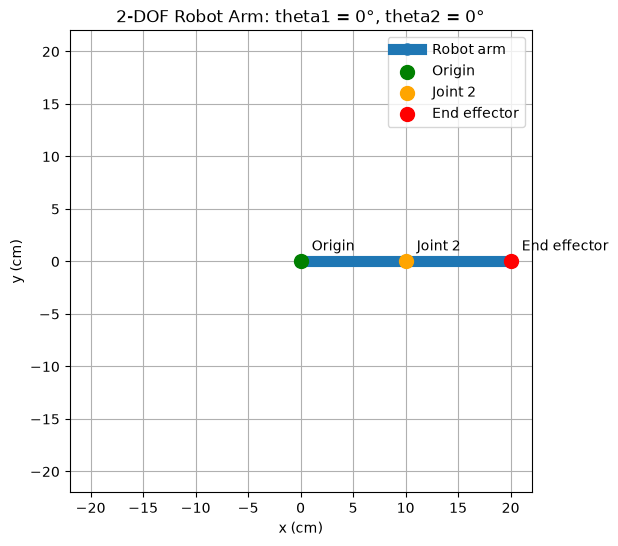

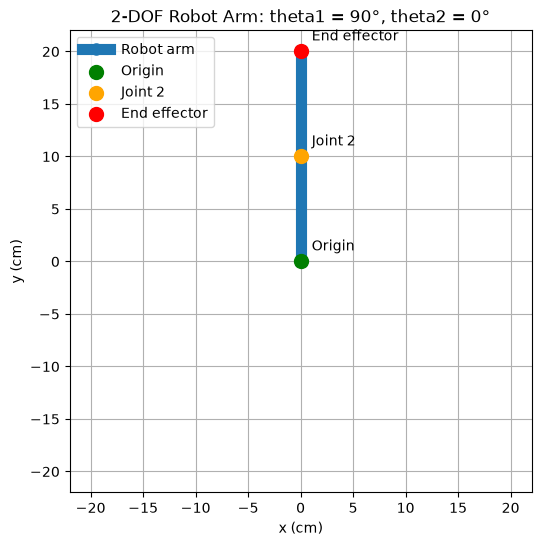

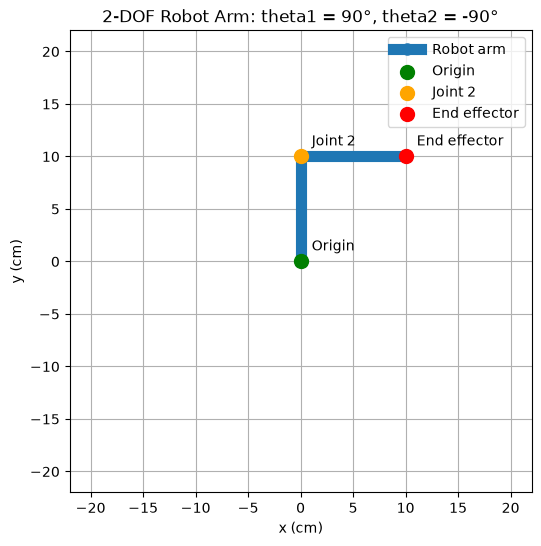

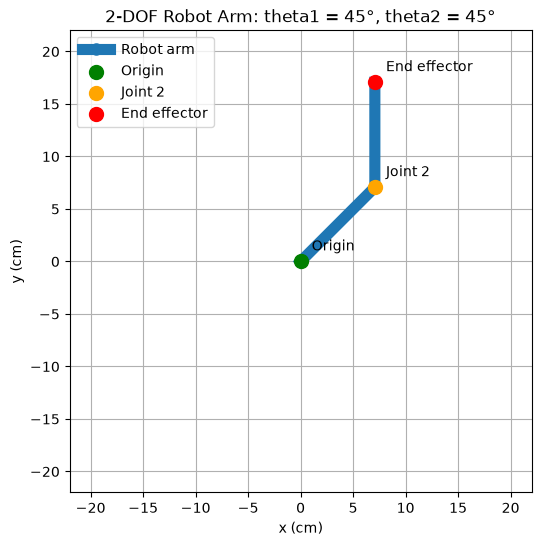

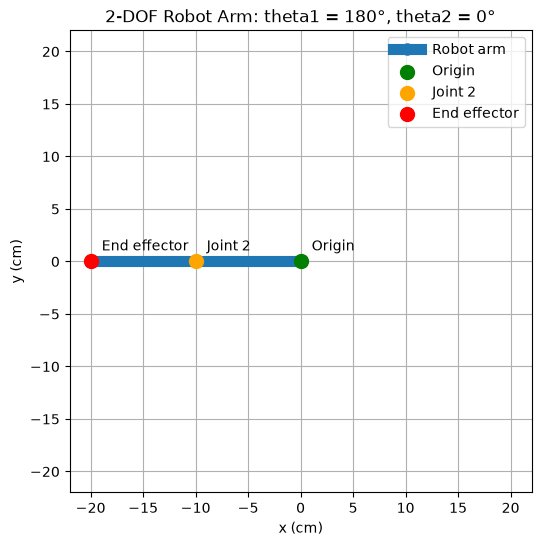

In [29]:
# visualize all five validated configurations:
for theta1, theta2, _ in configurations:
  plot_robot_configuration(robot, theta1, theta2)


Visual validation 

by verifing that those same configurations produce the expected physical geometry:

$$ (\theta_1,\theta_2) \rightarrow \text{Forward Kinematics} \rightarrow \text{Visualization} $$


### 2.3 - Interactive Joint Control

The interactive plot adds one slider for each joint angle. The two slider axes (`ax_theta1` and `ax_theta2`) must be created before the `Slider` objects; they are small control areas at the bottom of the figure, separate from the robot plot axis.

When a slider changes, the callback reads both current slider values, calls the validated forward-kinematics model through `plot_robot_configuration`, and redraws the robot in its new configuration.


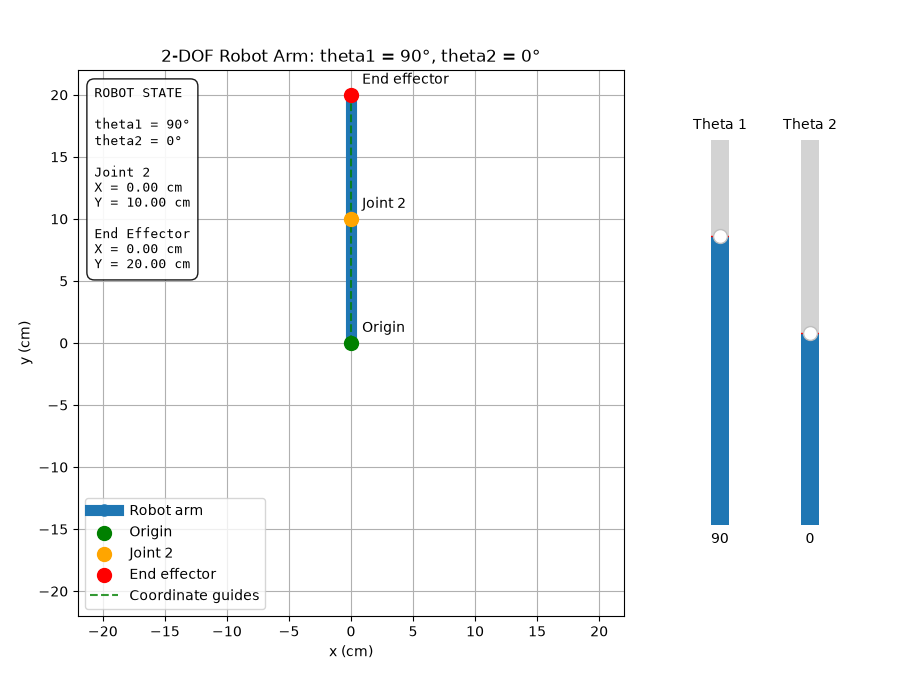

In [10]:
# Enable Matplotlib's interactive widget backend.
%matplotlib widget

# Import the Slider widget used to control each joint angle.
from matplotlib.widgets import Slider

# Create a wide figure with a main axis for the robot.
fig_interactive, ax_robot = plt.subplots(figsize=(9, 7))

# Reserve the right side of the figure for the vertical sliders.
ax_robot.set_position([0.08, 0.12, 0.62, 0.78])

# Calculate the initial robot points once.
initial_theta1 = 90
initial_theta2 = 0
origin, joint2, end_effector = robot.forward_kinematics(initial_theta1, initial_theta2)
points = [origin, joint2, end_effector]
x_coordinates, y_coordinates = zip(*points)

# Create the robot line once; the callback will update its coordinates.
robot_line, = ax_robot.plot(
    x_coordinates,
    y_coordinates,
    "o-",
    color="tab:blue",
    linewidth=8,
    markersize=8,
    label="Robot arm",
)

# Create the joint markers once; the callback will move them.
origin_marker = ax_robot.scatter(*origin, color="green", s=100, zorder=3, label="Origin")
joint2_marker = ax_robot.scatter(*joint2, color="orange", s=100, zorder=3, label="Joint 2")
end_effector_marker = ax_robot.scatter(
    *end_effector,
    color="red",
    s=100,
    zorder=3,
    label="End effector",
)

# Create dashed guides from the end effector to the x- and y-axes.
end_effector_x_guide, = ax_robot.plot(
    [0, end_effector[0]],
    [end_effector[1], end_effector[1]],
    "--",
    color="green",
    linewidth=1.5,
    alpha=0.8,
    label="Coordinate guides",
)
end_effector_y_guide, = ax_robot.plot(
    [end_effector[0], end_effector[0]],
    [0, end_effector[1]],
    "--",
    color="green",
    linewidth=1.5,
    alpha=0.8,
)

# Add point labels once and update their anchor points during interaction.
origin_label = ax_robot.annotate("Origin", origin, xytext=(8, 8), textcoords="offset points")
joint2_label = ax_robot.annotate("Joint 2", joint2, xytext=(8, 8), textcoords="offset points")
end_effector_label = ax_robot.annotate(
    "End effector",
    end_effector,
    xytext=(8, 8),
    textcoords="offset points",
)

# Create one text box for the robot's current internal state.
def format_robot_state(theta1, theta2, joint2, end_effector):
    # Format angles and coordinates into readable lines.
    return (
        "ROBOT STATE\n"
        "\n"
        f"theta1 = {theta1:.0f}°\n"
        f"theta2 = {theta2:.0f}°\n"
        "\n"
        "Joint 2\n"
        f"X = {joint2[0]:.2f} cm\n"
        f"Y = {joint2[1]:.2f} cm\n"
        "\n"
        "End Effector\n"
        f"X = {end_effector[0]:.2f} cm\n"
        f"Y = {end_effector[1]:.2f} cm"
    )


state_text = ax_robot.text(
    0.03,
    0.97,
    format_robot_state(initial_theta1, initial_theta2, joint2, end_effector),
    transform=ax_robot.transAxes,
    verticalalignment="top",
    family="monospace",
    fontsize=9,
    bbox={"boxstyle": "round,pad=0.6", "facecolor": "white", "alpha": 0.9},
)

# Set the plot limits and appearance once because the robot reach is fixed.
maximum_reach = robot.L1 + robot.L2
padding = max(2, maximum_reach * 0.1)
ax_robot.set_xlim(-maximum_reach - padding, maximum_reach + padding)
ax_robot.set_ylim(-maximum_reach - padding, maximum_reach + padding)
ax_robot.set_aspect("equal", adjustable="box")
ax_robot.set_xlabel("x (cm)")
ax_robot.set_ylabel("y (cm)")
ax_robot.grid(True)
ax_robot.legend()

# Create a dedicated axis for each vertical slider on the right.
ax_theta1 = fig_interactive.add_axes([0.78, 0.25, 0.04, 0.55])
ax_theta2 = fig_interactive.add_axes([0.88, 0.25, 0.04, 0.55])

# Create sliders with one-degree steps.
slider_theta1 = Slider(
    ax_theta1,
    "Theta 1",
    -180,
    180,
    valinit=initial_theta1,
    valstep=1,
    orientation="vertical",
)
slider_theta2 = Slider(
    ax_theta2,
    "Theta 2",
    -180,
    180,
    valinit=initial_theta2,
    valstep=1,
    orientation="vertical",
)


def update_robot(_):
    # Read the current integer-degree values from both sliders.
    theta1 = slider_theta1.val
    theta2 = slider_theta2.val

    # Calculate the new robot points using forward kinematics.
    origin, joint2, end_effector = robot.forward_kinematics(theta1, theta2)
    x_coordinates, y_coordinates = zip(origin, joint2, end_effector)

    # Update existing artists instead of clearing and recreating the plot.
    robot_line.set_data(x_coordinates, y_coordinates)
    origin_marker.set_offsets([origin])
    joint2_marker.set_offsets([joint2])
    end_effector_marker.set_offsets([end_effector])

    # Move the dashed guides so they continue to mark the end-effector coordinates.
    end_effector_x_guide.set_data([0, end_effector[0]], [end_effector[1], end_effector[1]])
    end_effector_y_guide.set_data([end_effector[0], end_effector[0]], [0, end_effector[1]])

    # Move each annotation anchor while keeping its pixel offset.
    origin_label.xy = origin
    joint2_label.xy = joint2
    end_effector_label.xy = end_effector

    # Update the state box with the newly calculated values.
    state_text.set_text(format_robot_state(theta1, theta2, joint2, end_effector))

    # Update the title without rebuilding the rest of the figure.
    ax_robot.set_title(f"2-DOF Robot Arm: theta1 = {theta1:.0f}°, theta2 = {theta2:.0f}°")

    # Refresh the displayed interactive figure.
    fig_interactive.canvas.draw_idle()


# Connect both sliders to the update function.
slider_theta1.on_changed(update_robot)
slider_theta2.on_changed(update_robot)

# Set the initial title and display the interactive figure.
ax_robot.set_title(
    f"2-DOF Robot Arm: theta1 = {initial_theta1}°, theta2 = {initial_theta2}°"
)
plt.show()


## 3.Automatic Configuration-Space Dataset Generator

Now we're going to make the computer explore the robot's possible configurations automatically.
The goal is to create a dataset containing relationships like:

|    θ₁ |     θ₂ |     X |     Y |
| ----: | -----: | ----: | ----: |
|  0.0° |   0.0° | 20.00 |  0.00 |
|  0.0° |   1.0° | 19.99 |  0.17 |
|  0.0° |   2.0° | 19.99 |  0.35 |
|   ... |    ... |   ... |   ... |
| 90.0° | -90.0° | 10.00 | 10.00 |


### 3.1 Configuration Space vs Workspace

       θ1 ──────┐
                │
       θ2 ──────┤
                ↓
          Forward Kinematics
                ↓
             (x, y)
                ↓
             Dataset

In [4]:
theta1_min = -90
theta1_max = 180

theta2_min = -120
theta2_max = 120

setting the limmit of exploring to step = 1° & considering the joint limmits  

We can generate:

$$ 271 \times 241 $$

configurations.
  
That's:

65,311 

	​That's already a substantial dataset.


In [5]:
# Import Pandas for the tabular dataset and Path for portable file handling.
import pandas as pd
from pathlib import Path


def generate_dataset(robot, theta1_range, theta2_range, step):
    """Generate one row for every valid pair of joint angles."""
    # Build inclusive angle arrays using the requested step size.
    theta1_values = np.arange(theta1_range[0], theta1_range[1] + step, step, dtype=float)
    theta2_values = np.arange(theta2_range[0], theta2_range[1] + step, step, dtype=float)

    # Store each configuration and its end-effector position in a list.
    rows = []
    for theta1 in theta1_values:
        for theta2 in theta2_values:
            # Use the existing RobotArm2DOF forward-kinematics implementation.
            _, _, end_effector = robot.forward_kinematics(theta1, theta2)
            rows.append(
                {
                    "theta1": theta1,
                    "theta2": theta2,
                    "x": end_effector[0],
                    "y": end_effector[1],
                }
            )

    # Convert all generated rows into a Pandas DataFrame.
    return pd.DataFrame(rows, columns=["theta1", "theta2", "x", "y"])


# Define the joint limits and the one-degree sampling resolution.
theta1_range = (theta1_min, theta1_max)
theta2_range = (theta2_min, theta2_max)
step = 1.0

# Generate the complete configuration-space dataset.
dataset = generate_dataset(robot, theta1_range, theta2_range, step)

# Print the number of generated configurations.
print(f"Number of configurations: {len(dataset):,}")

# Inspect the first five rows of the dataset.
display(dataset.head())

# Print basic descriptive statistics for all dataset columns.
display(dataset.describe())

# Create the data directory if it does not already exist.
data_directory = Path("data")
data_directory.mkdir(parents=True, exist_ok=True)

# Save the dataset as a CSV file without the Pandas index column.
dataset_path = data_directory / "robot_configurations.csv"
dataset.to_csv(dataset_path, index=False)
print(f"Dataset saved to: {dataset_path}")


Number of configurations: 65,311


,theta1,theta2,x,y
0,-90.0,-120.0,-8.660254,-5.000000
1,-90.0,-119.0,-8.746197,-5.151904
2,-90.0,-118.0,-8.829476,-5.305284
3,-90.0,-117.0,-8.910065,-5.460095
4,-90.0,-116.0,-8.987940,-5.616289


,theta1,theta2,x,y
count,65311.000000,65311.000000,65311.000000,65311.000000
mean,45.000000,0.000000,2.954344,2.954344
std,78.231028,69.570641,11.499715,11.499715
min,-90.000000,-120.000000,-20.000000,-20.000000
25%,-23.000000,-60.000000,-7.035821,-7.035821
50%,45.000000,0.000000,5.169287,5.169287
75%,113.000000,60.000000,12.846288,12.846288
max,180.000000,120.000000,20.000000,20.000000


Dataset saved to: data\robot_configurations.csv


## 3.2 Reachable-workspace visualization and analysis

**Configuration space** describes the robot using joint angles $(\theta_1,\theta_2)$, in degrees. Our sampled configuration space is a rectangular grid: $-90^\circ \leq \theta_1 \leq 180^\circ$ and $-120^\circ \leq \theta_2 \leq 120^\circ$, at one-degree intervals (65,311 configurations).

**Cartesian workspace** describes the corresponding end-effector positions $(x,y)$, in centimetres. The existing `robot.forward_kinematics` maps each configuration to one Cartesian position. This section reads those positions from the saved CSV; it does not implement another forward-kinematics model or regenerate the data.

Run the robot-definition cells above first (NumPy, `RobotArm2DOF`, and `robot`), and run this section from the repository directory. Dataset generation need not be rerun. The CSV remains raw configuration-space data, **not an ANN training dataset**.

The limits here are the dataset generator's limits. The earlier simulation sliders currently allow wider angles, and the class does not enforce joint limits, so a configuration shown by those sliders is not necessarily part of this workspace.

In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from IPython.display import Image, display
from io import BytesIO

def display_workspace_figure(figure):
    """Display a static PNG without changing the interactive backend."""
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=140)
    display(Image(data=buffer.getvalue()))

# Read the existing raw data without modifying it.
workspace_data = pd.read_csv(Path("data") / "robot_configurations.csv")
assert list(workspace_data.columns) == ["theta1", "theta2", "x", "y"]
assert np.isfinite(workspace_data.to_numpy()).all(), "Data must be finite."
assert len(workspace_data) == 271 * 241
assert not workspace_data.duplicated(["theta1", "theta2"]).any()
np.testing.assert_array_equal(np.sort(workspace_data.theta1.unique()), np.arange(-90, 181))
np.testing.assert_array_equal(np.sort(workspace_data.theta2.unique()), np.arange(-120, 121))

# Check every saved position against the existing, array-compatible model.
_, _, saved_model_position = robot.forward_kinematics(
    workspace_data.theta1.to_numpy(), workspace_data.theta2.to_numpy()
)
np.testing.assert_allclose(
    workspace_data[["x", "y"]].to_numpy(),
    np.column_stack(saved_model_position), rtol=0, atol=1e-9,
)
print(f"Validated {len(workspace_data):,} saved configurations against the existing robot model.")

Validated 65,311 saved configurations against the existing robot model.


### Cartesian bounds and radial reach

For each saved point, its distance from the base is $r=\sqrt{x^2+y^2}$. `np.hypot(x, y)` computes this distance. The theoretical upper bound is $L_1+L_2$, reached when the links align ($\theta_2=0^\circ$), which is allowed in our dataset.

The existing model rounds coordinates to ten decimal places, so numerical comparisons use a small absolute tolerance of $10^{-9}$ cm rather than exact floating-point equality.

In [5]:
radius = np.hypot(workspace_data.x, workspace_data.y)
theoretical_max_radius = robot.L1 + robot.L2
workspace_summary = pd.DataFrame({
    "Quantity": ["Minimum X", "Maximum X", "Minimum Y", "Maximum Y",
                 "Minimum radius", "Maximum radius", "Theoretical maximum radius"],
    "Distance (cm)": [workspace_data.x.min(), workspace_data.x.max(),
                      workspace_data.y.min(), workspace_data.y.max(),
                      radius.min(), radius.max(), theoretical_max_radius],
})
display(workspace_summary.style.format({"Distance (cm)": "{:.6f}"}).hide(axis="index"))
radius_difference = abs(radius.max() - theoretical_max_radius)
print(f"Absolute maximum-radius difference: {radius_difference:.3e} cm")
np.testing.assert_allclose(radius.max(), theoretical_max_radius, rtol=0, atol=1e-9)
assert (radius <= theoretical_max_radius + 1e-9).all()
print("Measured maximum radius agrees with L1 + L2 within 1e-9 cm.")

Quantity,Distance (cm)
Minimum X,-20.000000
Maximum X,20.000000
Minimum Y,-20.000000
Maximum Y,20.000000
Minimum radius,10.000000
Maximum radius,20.000000
Theoretical maximum radius,20.000000


Absolute maximum-radius difference: 1.309e-10 cm
Measured maximum radius agrees with L1 + L2 within 1e-9 cm.


### All sampled end-effector positions

Plot every CSV row with equal scaling on both axes, so distances and shapes retain their physical meaning. The dashed circle is the theoretical maximum reach; it does not imply that every point inside it is reachable. The black cross marks the base, not a reachable end-effector position.

These are samples of the continuous workspace at one-degree joint resolution. Their density is not uniform in Cartesian space, and overlapping points may hide one another. The plot describes end-effector reach under joint limits only; obstacles and collisions are not modeled here.

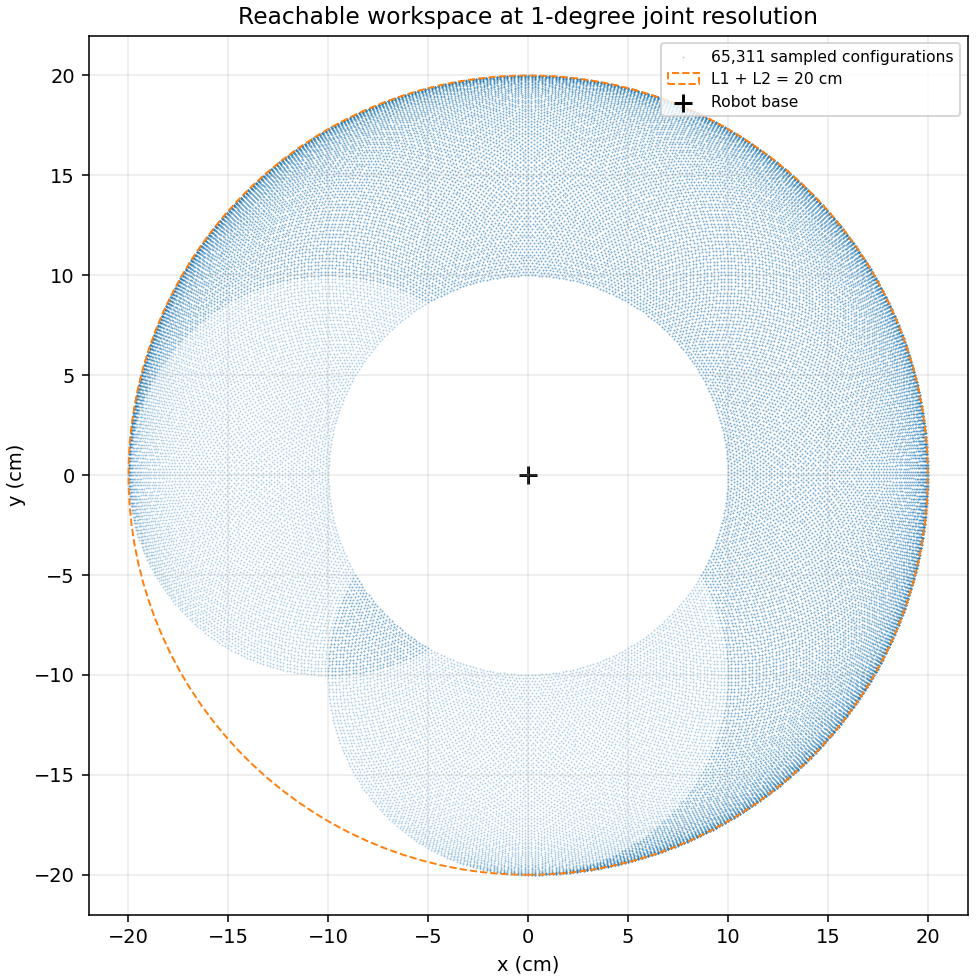

In [6]:
# Explicit static figures preserve the earlier interactive slider backend.
workspace_figure = Figure(figsize=(7, 7), layout="constrained")
workspace_ax = workspace_figure.subplots()
workspace_ax.scatter(workspace_data.x, workspace_data.y, s=1, alpha=0.35,
                     color="tab:blue", linewidths=0, label="65,311 sampled configurations")
workspace_ax.add_patch(plt.Circle((0, 0), theoretical_max_radius, fill=False,
                                  color="tab:orange", linestyle="--", label="L1 + L2 = 20 cm"))
workspace_ax.scatter(0, 0, marker="+", color="black", s=90, label="Robot base")
workspace_ax.set(xlabel="x (cm)", ylabel="y (cm)",
                 title="Reachable workspace at 1-degree joint resolution",
                 xlim=(-22, 22), ylim=(-22, 22), aspect="equal")
workspace_ax.grid(alpha=0.25)
workspace_ax.legend(loc="upper right", fontsize=8)
display_workspace_figure(workspace_figure)

### Map configuration space into Cartesian workspace using $\theta_2$

The two panels below use the same rows and the same colour scale. On the left, the angles form a rectangular grid. On the right, their saved positions form the workspace. Colour shows the signed relative angle of Link 2: straight configurations ($\theta_2=0^\circ$) lie at maximum reach; stronger bending moves the end effector inward.

A single colour plot is simple, but the last point drawn can cover another configuration at the same position. **Visible colour does not identify a unique configuration.** We retain every row and make no inverse-kinematics configuration policy here; investigating that ambiguity belongs to Step 3.3 after review.

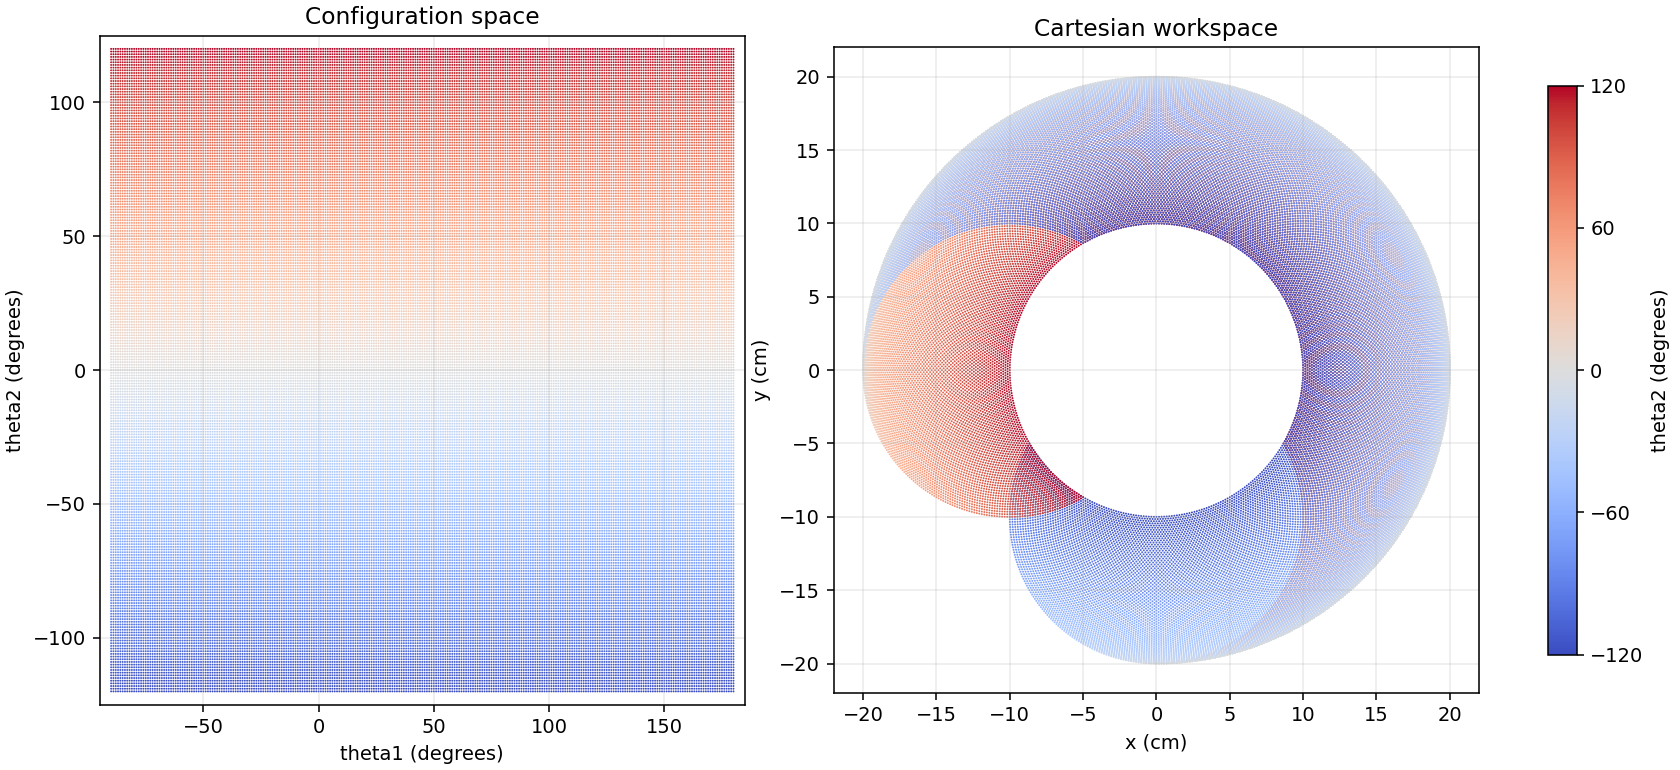

In [7]:
configuration_figure = Figure(figsize=(12, 5.5), layout="constrained")
configuration_axes = configuration_figure.subplots(1, 2)
colour_options = dict(c=workspace_data.theta2, cmap="coolwarm", vmin=-120, vmax=120,
                      s=1, linewidths=0)
configuration_axes[0].scatter(workspace_data.theta1, workspace_data.theta2, **colour_options)
configuration_axes[0].set(xlabel="theta1 (degrees)", ylabel="theta2 (degrees)",
                           title="Configuration space", xlim=(-95, 185), ylim=(-125, 125))
workspace_colours = configuration_axes[1].scatter(workspace_data.x, workspace_data.y,
                                                **colour_options)
configuration_axes[1].set(xlabel="x (cm)", ylabel="y (cm)", title="Cartesian workspace",
                           xlim=(-22, 22), ylim=(-22, 22), aspect="equal")
for ax in configuration_axes:
    ax.grid(alpha=0.25)
configuration_figure.colorbar(workspace_colours, ax=list(configuration_axes),
                              label="theta2 (degrees)", ticks=[-120, -60, 0, 60, 120], shrink=0.85)
display_workspace_figure(configuration_figure)

### Interpretation: what the joint limits change

For this dataset, X and Y each range from **-20 to +20 cm**, and the radius ranges from **10 to 20 cm** (within numerical rounding). These axis bounds describe a bounding box, not a filled square or disk.

The radial identity derived from the existing forward-kinematics equations is

$$r^2=L_1^2+L_2^2+2L_1L_2\cos(\theta_2).$$

With both links 10 cm, $\theta_2=0^\circ$ gives $r=20$ cm, while $\theta_2=\pm120^\circ$ gives $r=10$ cm. The second joint cannot fold to $180^\circ$, so the central region $r<10$ cm is unreachable. This identity explains the measurements; it is not a replacement Cartesian forward-kinematics implementation.

The first joint's range is only $270^\circ$. It restricts the directions in which the bent arm can point, producing the missing outer region toward the lower left. Thus even some points between radii 10 and 20 cm are unreachable. Nevertheless, straight configurations at $\theta_1=-90^\circ,0^\circ,90^\circ,180^\circ$ reach the four axis extrema, explaining why the bounding box is symmetric while the workspace is not a complete annulus.

**Step 3.2 ends here.** The raw CSV is unchanged. Review the workspace and numerical results before Step 3.3; configuration selection, ML data preparation, and ANN training remain future work.

## 3.3 Resolve inverse-kinematics ambiguity and prepare the ML dataset

This step combines ambiguity investigation, configuration selection, and dataset preparation. Forward kinematics maps each $(\theta_1,\theta_2)$ to one $(x,y)$, but the reverse mapping can have two valid joint configurations. Giving ordinary regression the same input with different angle labels can encourage it to average incompatible solutions; those averaged angles need not reach the target.

Run the existing NumPy, `RobotArm2DOF`, and `robot` definition cells first. This section can then run independently of the dataset generator and interactive UI, from the repository directory. It reads the raw CSV, selects existing rows, and writes a separate training CSV. No ANN is trained.

### 3.3A Investigate approximately equal Cartesian targets

We group by X and Y rounded to **six decimal places in cm** (a $10^{-6}$ cm grid). Original coordinates remain unchanged. This is much finer than the one-degree configuration sampling, yet coarser than the model's ten-decimal coordinate rounding. Rounded bins are not a general distance-clustering algorithm: nearby values can fall on opposite sides of a bin boundary. We therefore also check agreement across five, six, and seven decimals and verify that every mathematically paired configuration in this grid receives the same key. Group spreads and forward-kinematics reconstruction use a stricter $10^{-9}$ cm tolerance.

In [4]:
from pathlib import Path
from hashlib import sha256
import pandas as pd
from IPython.display import display

raw_path = Path("data/robot_configurations.csv")
raw_digest = sha256(raw_path.read_bytes()).hexdigest()
raw_ik = pd.read_csv(raw_path)
assert list(raw_ik.columns) == ["theta1", "theta2", "x", "y"]
assert len(raw_ik) == 271 * 241
assert np.isfinite(raw_ik.to_numpy()).all()
assert not raw_ik.duplicated(["theta1", "theta2"]).any()
np.testing.assert_array_equal(np.sort(raw_ik.theta1.unique()), np.arange(-90, 181))
np.testing.assert_array_equal(np.sort(raw_ik.theta2.unique()), np.arange(-120, 121))

key_columns = ["rounded_x", "rounded_y"]
analysis = raw_ik.assign(rounded_x=raw_ik.x.round(6), rounded_y=raw_ik.y.round(6))
groups = analysis.groupby(key_columns, sort=True)
group_sizes = groups.size()
group_spreads = groups[["x", "y"]].max() - groups[["x", "y"]].min()
assert group_sizes.max() == 2
assert group_spreads.to_numpy().max() <= 1e-9
rounding_checks = []
for decimals in [5, 6, 7]:
    keys = raw_ik[["x", "y"]].round(decimals)
    counts = keys.groupby(["x", "y"]).size()
    # Ensure each precision produces the same partition, not merely the same count.
    precision_check = analysis[key_columns].assign(px=keys.x, py=keys.y)
    assert precision_check.groupby(key_columns)[["px", "py"]].nunique().to_numpy().max() == 1
    assert precision_check.groupby(["px", "py"])[key_columns].nunique().to_numpy().max() == 1
    rounding_checks.append([decimals, len(counts), int((counts > 1).sum())])
display(pd.DataFrame(rounding_checks, columns=["Decimal places", "Cartesian groups", "Ambiguous groups"]))
print(f"Raw configurations: {len(raw_ik):,}")
print(f"Single-configuration targets: {(group_sizes == 1).sum():,}")
print(f"Maximum within-group coordinate spread: {group_spreads.to_numpy().max():.3e} cm")

# Show both configurations for three familiar targets already present in the data.
example_targets = [(10.0, 10.0), (10.0, 0.0), (0.0, 10.0)]
examples = analysis.set_index(key_columns).loc[example_targets].reset_index()
display(examples[["x", "y", "theta1", "theta2"]])

,Decimal places,Cartesian groups,Ambiguous groups
0,5,39555,25756
1,6,39555,25756
2,7,39555,25756


Raw configurations: 65,311
Single-configuration targets: 13,799
Maximum within-group coordinate spread: 0.000e+00 cm


,x,y,theta1,theta2
0,10.0,10.0,0.0,90.0
1,10.0,10.0,90.0,-90.0
2,10.0,0.0,-60.0,120.0
3,10.0,-0.0,60.0,-120.0
4,-0.0,10.0,30.0,120.0
5,0.0,10.0,150.0,-120.0


### Branch sign and the role of joint limits

For equal link lengths, the paired solution is $(\theta_1+\theta_2,-\theta_2)$, with the first angle adjusted by multiples of $360^\circ$ to test the permitted interval. This follows by exchanging the two equal-length link directions. It is used only to check the pairing and joint limits; Cartesian positions still come exclusively from the existing model and CSV.

In our convention, positive $\theta_2$ bends Link 2 counter-clockwise relative to Link 1. For a target on +X, this puts the elbow below the target ray (commonly called **elbow-down**); negative $\theta_2$ puts it above (**elbow-up**). More generally, positive $\theta_2$ places the elbow on the clockwise side of the base-to-target ray, and negative on the counter-clockwise side. The sign is less ambiguous than calling the elbow globally “up” or “down.” At $\theta_2=0$, the two branches coincide.

The next check enumerates the equivalent first-joint angles inside [-90, 180] degrees. Because this robot has equal links and an integer-degree grid, every valid paired configuration is also sampled. We verify its existence and rounded Cartesian key. This guards against missed pairings caused by floating-point bin boundaries.

In [5]:
angle_lookup = analysis.set_index(["theta1", "theta2"])
has_distinct_partner = []
for row in analysis.itertuples(index=False):
    candidates = [row.theta1 + row.theta2 + turn for turn in (-360, 0, 360)]
    valid_angles = [angle for angle in candidates if -90 <= angle <= 180]
    assert len(valid_angles) <= 1
    has_partner = row.theta2 != 0 and bool(valid_angles)
    has_distinct_partner.append(has_partner)
    if has_partner:
        partner = angle_lookup.loc[(valid_angles[0], -row.theta2)]
        assert (partner.rounded_x, partner.rounded_y) == (row.rounded_x, row.rounded_y)
        np.testing.assert_allclose([partner.x, partner.y], [row.x, row.y], rtol=0, atol=1e-9)

analysis["number_of_solutions"] = groups["theta1"].transform("size")
np.testing.assert_array_equal(has_distinct_partner, analysis.number_of_solutions.to_numpy() == 2)
branch_bounds = groups.theta2.agg(["min", "max"])
ambiguous = group_sizes > 1
assert (branch_bounds.loc[ambiguous, "min"] < 0).all()
assert (branch_bounds.loc[ambiguous, "max"] > 0).all()
preferred_targets = analysis.loc[analysis.theta2 >= 0, key_columns].drop_duplicates()
fallback_target_count = len(group_sizes) - len(preferred_targets)
print(f"Targets retained by theta2 >= 0 alone: {len(preferred_targets):,}")
print(f"Reachable targets lost without a fallback: {fallback_target_count:,}")
print("Every two-solution group has opposite theta2 signs; partner checks passed.")
# A negative-only example and its invalid positive-branch first angle.
fallback_example = analysis.loc[(analysis.theta2 < 0) & (analysis.number_of_solutions == 1)].iloc[[0]].copy()
fallback_example["alternate_theta1_unwrapped"] = fallback_example.theta1 + fallback_example.theta2
display(fallback_example[["x", "y", "theta1", "theta2", "alternate_theta1_unwrapped"]])

Targets retained by theta2 >= 0 alone: 32,791
Reachable targets lost without a fallback: 6,764
Every two-solution group has opposite theta2 signs; partner checks passed.


,x,y,theta1,theta2,alternate_theta1_unwrapped
31,-9.998477,-10.174524,-90.0,-89.0,-179.0


### 3.3B Our first deterministic inverse-kinematics policy

1. Prefer **positive $\theta_2$** when both branches are valid.
2. Retain **negative $\theta_2$** when the positive branch is unavailable under the joint limits.
3. Retain straight configurations ($\theta_2=0$), where there is only one solution.

Sort by this preference, then by joint angles to make ordering reproducible, and keep one original row per Cartesian key. We do not average positions or angles. Helpers are excluded from the final CSV; its columns are `x, y, theta1, theta2`.

The investigation finds **25,756 ambiguous targets** among **39,555 Cartesian groups**. A positive-only policy would retain 32,791 targets and lose 6,764. The fallback preserves the full sampled workspace and gives each target one desired configuration.

**Advantages:** simple labels, deterministic selection, and complete sampled workspace coverage. **Disadvantages:** the selected angles can jump where the preferred branch ceases to satisfy joint limits. Unique labels therefore do not guarantee a smooth or easy regression problem. A future ANN must be assessed carefully near these boundaries, with predictions checked through forward kinematics and against joint limits. This dataset resolves label ambiguity; it is not a claim of trained-model accuracy, and splitting/scaling remain Step 4 work.

This is our **first IK policy**. A future state-aware approach could combine the current joint configuration with a target and select a nearby, safe valid solution to reduce joint movement. That may better support trajectories, but requires a different input/selection design and is not implemented here.

In [6]:
analysis["branch_priority"] = (analysis.theta2 < 0).astype(int)
selected = (analysis.sort_values(["branch_priority", "theta1", "theta2"])
            .drop_duplicates(key_columns)
            .sort_values(key_columns)
            .reset_index(drop=True))
ik_training = selected[["x", "y", "theta1", "theta2"]].copy()
print(f"Selected samples: {len(ik_training):,}")
print(f"Positive theta2: {(ik_training.theta2 > 0).sum():,}")
print(f"Straight theta2: {(ik_training.theta2 == 0).sum():,}")
print(f"Negative fallback: {(ik_training.theta2 < 0).sum():,}")
display(ik_training.head())

Selected samples: 39,555
Positive theta2: 32,520
Straight theta2: 271
Negative fallback: 6,764


,x,y,theta1,theta2
0,-20.000000,0.000000,180.0,0.0
1,-19.998477,-0.174524,180.0,1.0
2,-19.998477,0.174524,179.0,1.0
3,-19.996954,0.000000,179.0,2.0
4,-19.996954,0.349048,179.0,0.0


### 3.3C Validate, then save a separate ML dataset

Checks below enforce one selected target per six-decimal Cartesian key, retention of every raw target group, preferred-branch selection wherever possible, valid joint limits, and unchanged raw data. Selected angles are reconstructed using **`robot.forward_kinematics`**, with Cartesian error at most $10^{-9}$ cm. We also verify the written CSV after loading it again.

The result is a deterministic supervised dataset: input `[x, y]` in cm, output `[theta1, theta2]` in degrees. No helper columns or normalized values are saved. Keep the raw configuration-space data for future alternative policies.

In [7]:
training_keys = ik_training[["x", "y"]].round(6)
assert not training_keys.duplicated().any(), "Conflicting Cartesian labels remain."
assert len(ik_training) == len(group_sizes)
assert set(map(tuple, selected[key_columns].to_numpy())) == set(group_sizes.index)
assert np.isfinite(ik_training.to_numpy()).all()
assert ik_training.theta1.between(-90, 180).all()
assert ik_training.theta2.between(-120, 120).all()
assert (selected.loc[selected.number_of_solutions == 2, "theta2"] > 0).all()
assert (selected.loc[selected.theta2 < 0, "number_of_solutions"] == 1).all()
assert (selected.theta2 < 0).sum() == fallback_target_count

# Verify the result is independent of input row order.
reshuffled = (analysis.sample(frac=1, random_state=33)
              .sort_values(["branch_priority", "theta1", "theta2"])
              .drop_duplicates(key_columns).sort_values(key_columns)
              .reset_index(drop=True))
pd.testing.assert_frame_equal(ik_training, reshuffled[ik_training.columns])

_, _, reconstructed = robot.forward_kinematics(
    ik_training.theta1.to_numpy(), ik_training.theta2.to_numpy())
cartesian_errors = np.linalg.norm(
    np.column_stack(reconstructed) - ik_training[["x", "y"]].to_numpy(), axis=1)
assert cartesian_errors.max() <= 1e-9
training_radius = np.hypot(ik_training.x, ik_training.y)
np.testing.assert_allclose(training_radius.max(), robot.L1 + robot.L2, rtol=0, atol=1e-9)
display(ik_training.agg(["min", "max"]))
print(f"Raw rows: {len(raw_ik):,}")
print(f"Ambiguous Cartesian groups: {(group_sizes > 1).sum():,}")
print(f"Selected rows / unique Cartesian targets: {len(ik_training):,} / {len(training_keys.drop_duplicates()):,}")
print(f"Maximum reachable radius: {training_radius.max():.9f} cm")
print(f"Maximum FK reconstruction error: {cartesian_errors.max():.3e} cm")
print("Duplicate/conflicting targets at six-decimal precision: 0")

training_path = Path("data/robot_ik_training.csv")
assert sha256(raw_path.read_bytes()).hexdigest() == raw_digest
ik_training.to_csv(training_path, index=False)
reloaded_training = pd.read_csv(training_path)
pd.testing.assert_frame_equal(reloaded_training, ik_training, check_exact=False, rtol=0, atol=1e-12)
assert not reloaded_training[["x", "y"]].round(6).duplicated().any()
assert sha256(raw_path.read_bytes()).hexdigest() == raw_digest
print(f"Saved and verified: {training_path}; raw CSV unchanged.")

,x,y,theta1,theta2
min,-20.0,-20.0,-90.0,-120.0
max,20.0,20.0,180.0,120.0


Raw rows: 65,311
Ambiguous Cartesian groups: 25,756
Selected rows / unique Cartesian targets: 39,555 / 39,555
Maximum reachable radius: 20.000000000 cm
Maximum FK reconstruction error: 0.000e+00 cm
Duplicate/conflicting targets at six-decimal precision: 0


Saved and verified: data\robot_ik_training.csv; raw CSV unchanged.


### Step 3.3 result and review checkpoint

The raw 65,311 configurations produce **39,555 training samples**: 32,520 positive-branch samples, 271 straight configurations, and 6,764 negative-branch fallbacks. All 25,756 conflicting two-configuration groups now have a single selected label, while every sampled Cartesian target is retained. Both joint ranges and the X/Y bounds remain unchanged, with maximum reach 20 cm.

`data/robot_configurations.csv` remains the complete raw dataset. `data/robot_ik_training.csv` contains only the selected supervised samples. Review this first configuration policy and its boundary-discontinuity trade-off before Step 4. TensorFlow training has not started.

### Step 3.3 visual summary: fewer conflicting labels, same target coverage

The histogram counts **Cartesian target groups**, not dataset rows. Before selection, a target has one or two joint-angle labels. After selection, every target has exactly one. Both histograms use the same bins and axis scales. This is label-ambiguity resolution, not a measured improvement in ANN accuracy: all 39,555 sampled targets are retained while 25,756 alternate labels are removed.

The dashboard summarizes our first policy and the measured validation results. Run the Step 3.3 cells above first; all displayed counts are calculated from those results.

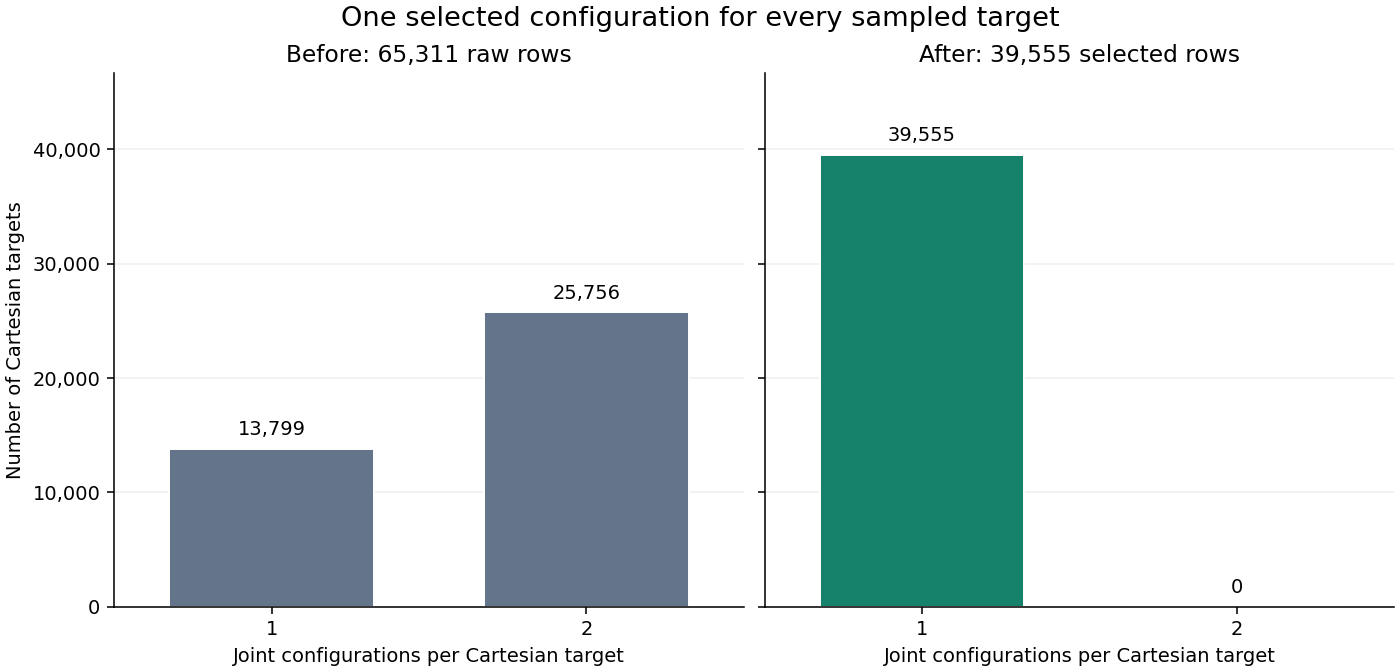

In [8]:
from io import BytesIO
from matplotlib.figure import Figure
from matplotlib.ticker import StrMethodFormatter
from IPython.display import Image, display

def show_ik_summary_figure(figure):
    """Render a static figure without changing the earlier slider backend."""
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=140, facecolor=figure.get_facecolor())
    display(Image(data=buffer.getvalue()))

clean_group_sizes = training_keys.groupby(["x", "y"]).size()
assert len(clean_group_sizes) == len(group_sizes)
assert clean_group_sizes.eq(1).all()
histogram_figure = Figure(figsize=(10, 4.8), layout="constrained")
histogram_axes = histogram_figure.subplots(1, 2, sharey=True)
for ax, counts, title, colour in zip(
    histogram_axes, [group_sizes, clean_group_sizes],
    [f"Before: {len(raw_ik):,} raw rows", f"After: {len(ik_training):,} selected rows"],
    ["#64748b", "#16826c"],
):
    heights, _, bars = ax.hist(counts, bins=[0.5, 1.5, 2.5], rwidth=0.65,
                               color=colour, edgecolor="white")
    ax.bar_label(bars, labels=[f"{int(value):,}" for value in heights], padding=5)
    ax.set(title=title, xlabel="Joint configurations per Cartesian target",
           xticks=[1, 2], xlim=(0.5, 2.5), ylim=(0, len(group_sizes) * 1.18))
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    ax.set_axisbelow(True)
    ax.grid(axis="y", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)
histogram_axes[0].set_ylabel("Number of Cartesian targets")
histogram_figure.suptitle("One selected configuration for every sampled target", fontsize=14)
show_ik_summary_figure(histogram_figure)

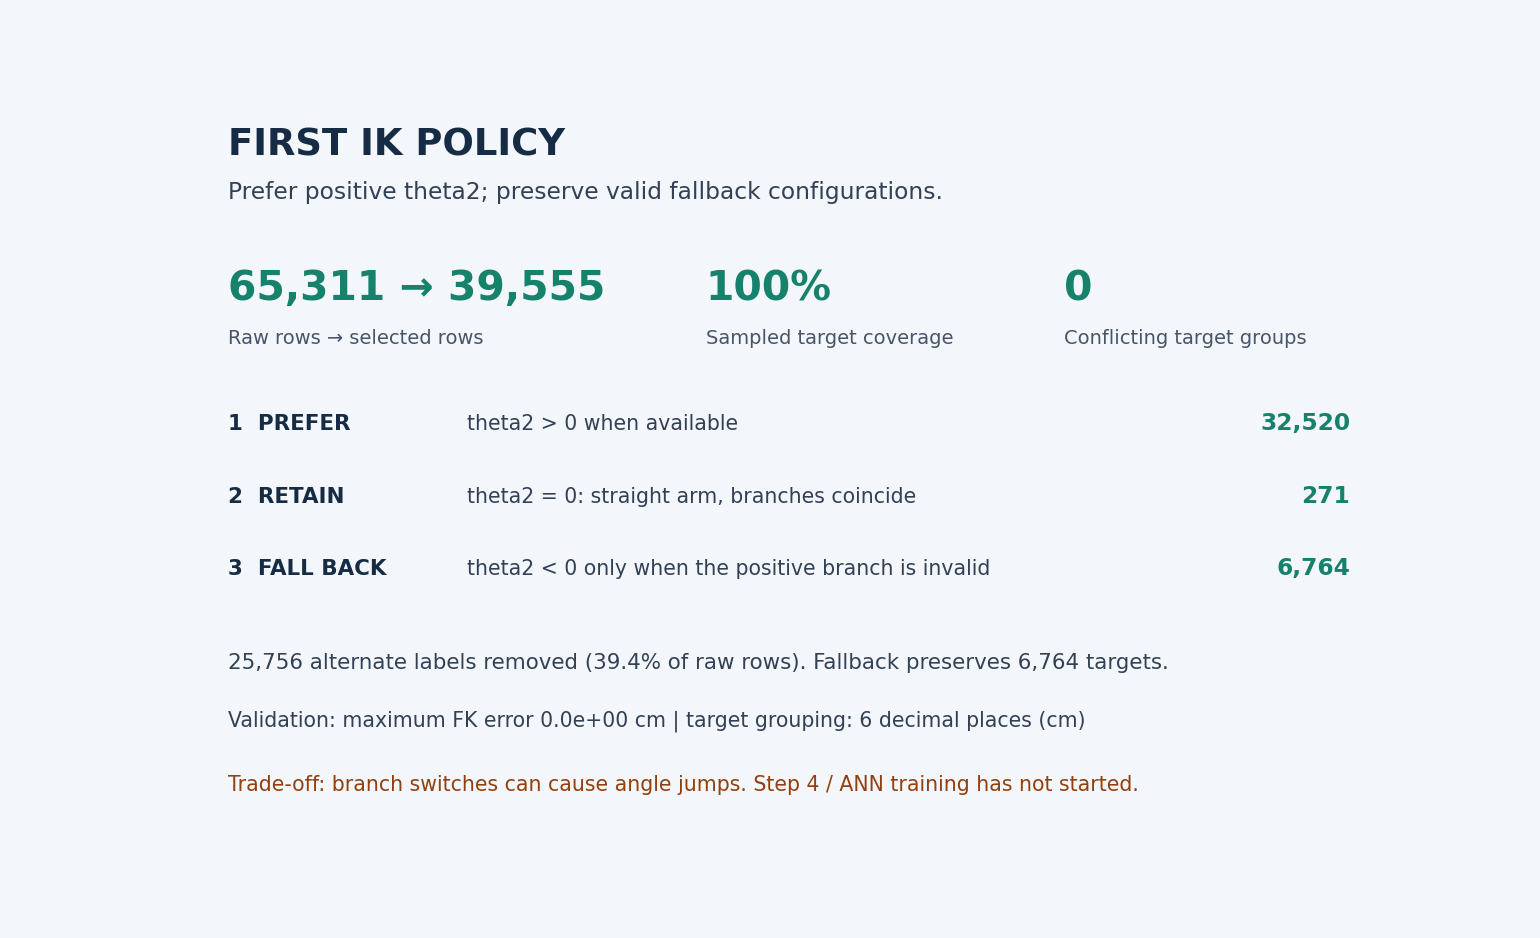

In [9]:
raw_count = len(raw_ik)
clean_count = len(ik_training)
removed_count = raw_count - clean_count
coverage = len(clean_group_sizes) / len(group_sizes)
positive_count = int((ik_training.theta2 > 0).sum())
straight_count = int((ik_training.theta2 == 0).sum())
fallback_count = int((ik_training.theta2 < 0).sum())
assert positive_count + straight_count + fallback_count == clean_count

policy_dashboard = Figure(figsize=(11, 6.7), facecolor="#f3f6fa")
dashboard_ax = policy_dashboard.subplots()
dashboard_ax.set_axis_off()
dashboard_ax.text(0.03, 0.94, "FIRST IK POLICY", fontsize=19, weight="bold", color="#162b44")
dashboard_ax.text(0.03, 0.88, "Prefer positive theta2; preserve valid fallback configurations.",
                  fontsize=12, color="#334155")

metrics = [
    (f"{raw_count:,} → {clean_count:,}", "Raw rows → selected rows"),
    (f"{coverage:.0%}", "Sampled target coverage"),
    (f"{int((clean_group_sizes > 1).sum()):,}", "Conflicting target groups"),
]
for x_position, (value, label) in zip([0.03, 0.43, 0.73], metrics):
    dashboard_ax.text(x_position, 0.74, value, fontsize=21, weight="bold", color="#16826c")
    dashboard_ax.text(x_position, 0.68, label, fontsize=10, color="#475569")

policy_rows = [
    ("1  PREFER", "theta2 > 0 when available", positive_count),
    ("2  RETAIN", "theta2 = 0: straight arm, branches coincide", straight_count),
    ("3  FALL BACK", "theta2 < 0 only when the positive branch is invalid", fallback_count),
]
for y_position, (label, rule, count) in zip([0.56, 0.46, 0.36], policy_rows):
    dashboard_ax.text(0.03, y_position, label, fontsize=11, weight="bold", color="#162b44")
    dashboard_ax.text(0.23, y_position, rule, fontsize=10.5, color="#334155")
    dashboard_ax.text(0.97, y_position, f"{count:,}", fontsize=12, weight="bold",
                      ha="right", color="#16826c")

dashboard_ax.text(0.03, 0.23,
    f"{removed_count:,} alternate labels removed ({removed_count / raw_count:.1%} of raw rows). "
    f"Fallback preserves {fallback_count:,} targets.", fontsize=11, color="#334155")
dashboard_ax.text(0.03, 0.15,
    f"Validation: maximum FK error {cartesian_errors.max():.1e} cm | "
    "target grouping: 6 decimal places (cm)", fontsize=10.5, color="#334155")
dashboard_ax.text(0.03, 0.06,
    "Trade-off: branch switches can cause angle jumps. Step 4 / ANN training has not started.",
    fontsize=10.5, color="#92400e")
show_ik_summary_figure(policy_dashboard)